## Nested Sampling
In this excercise we analyze the same dataset of the previous one, but this time we estimate the posterior distribuition of the parameters using Nested Sampling.


In [39]:
from dynesty import utils as dyfunc
import numpy as np
from matplotlib import pyplot as plt
path = 'C:/Users/alexv/Desktop/Università/astrostat/astrostatistics_bicocca_2025/solutions/transient.npy'
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)
from scipy.stats import loguniform
import warnings

Visualizing the data


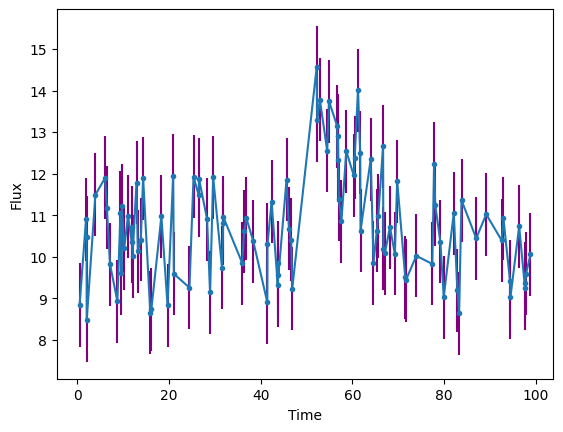

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\alexv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
data = np.load(path)
time = data[:,0]
flux = data[:,1]
err = data[:,2]
plt.errorbar(time, flux, yerr = err, ecolor = 'purple', marker = '.')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()
#Defining the same model of the previous excercise
def model(t, a, b, alfa, t0):
    
    arg = -alfa * (t - t0)
    arg = np.clip(arg, -700, 700)  # In order to avoid overflow
    temp = np.where(t < t0, b, b + a * np.exp(arg))
    return temp
   

!pip install dynesty


In [41]:
#Defining the prior volume with the same boundary condition of the previous case:
def ptform(u):
    a, b, u_alfa, t0 = u
    #unit cube
    alfa = loguniform.ppf(u_alfa, np.exp(-5), np.exp(5))
    
    return np.array([50 * a, 50 * b, alfa, 100 * t0])
    
def log_likelihood(theta, t, y, sigma):
    a, b, alfa, t0 = theta
    model_vals = model(t, a, b,alfa, t0)
    return -0.5 * np.sum(((y - model_vals) / sigma) ** 2)
#evidence off by costant factor, but i'm interest in their ratio bayes factor
def log_posterior(theta, t, y, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, sigma)

import dynesty

In [42]:
ndim = 4
with warnings.catch_warnings():
    
    warnings.simplefilter("ignore", category=RuntimeWarning)

#Running nested sampler
sampler = dynesty.NestedSampler(log_likelihood, ptform, ndim, logl_args=(time, flux, err), nlive = 1000) 
sresults = sampler.results

14828it [01:21, 181.14it/s, +1000 | bound: 118 | nc: 1 | ncall: 212355 | eff(%):  7.489 | loglstar:   -inf < -48.760 <    inf | logz: -63.488 +/-  0.125 | dlogz:  0.001 >  1.009]


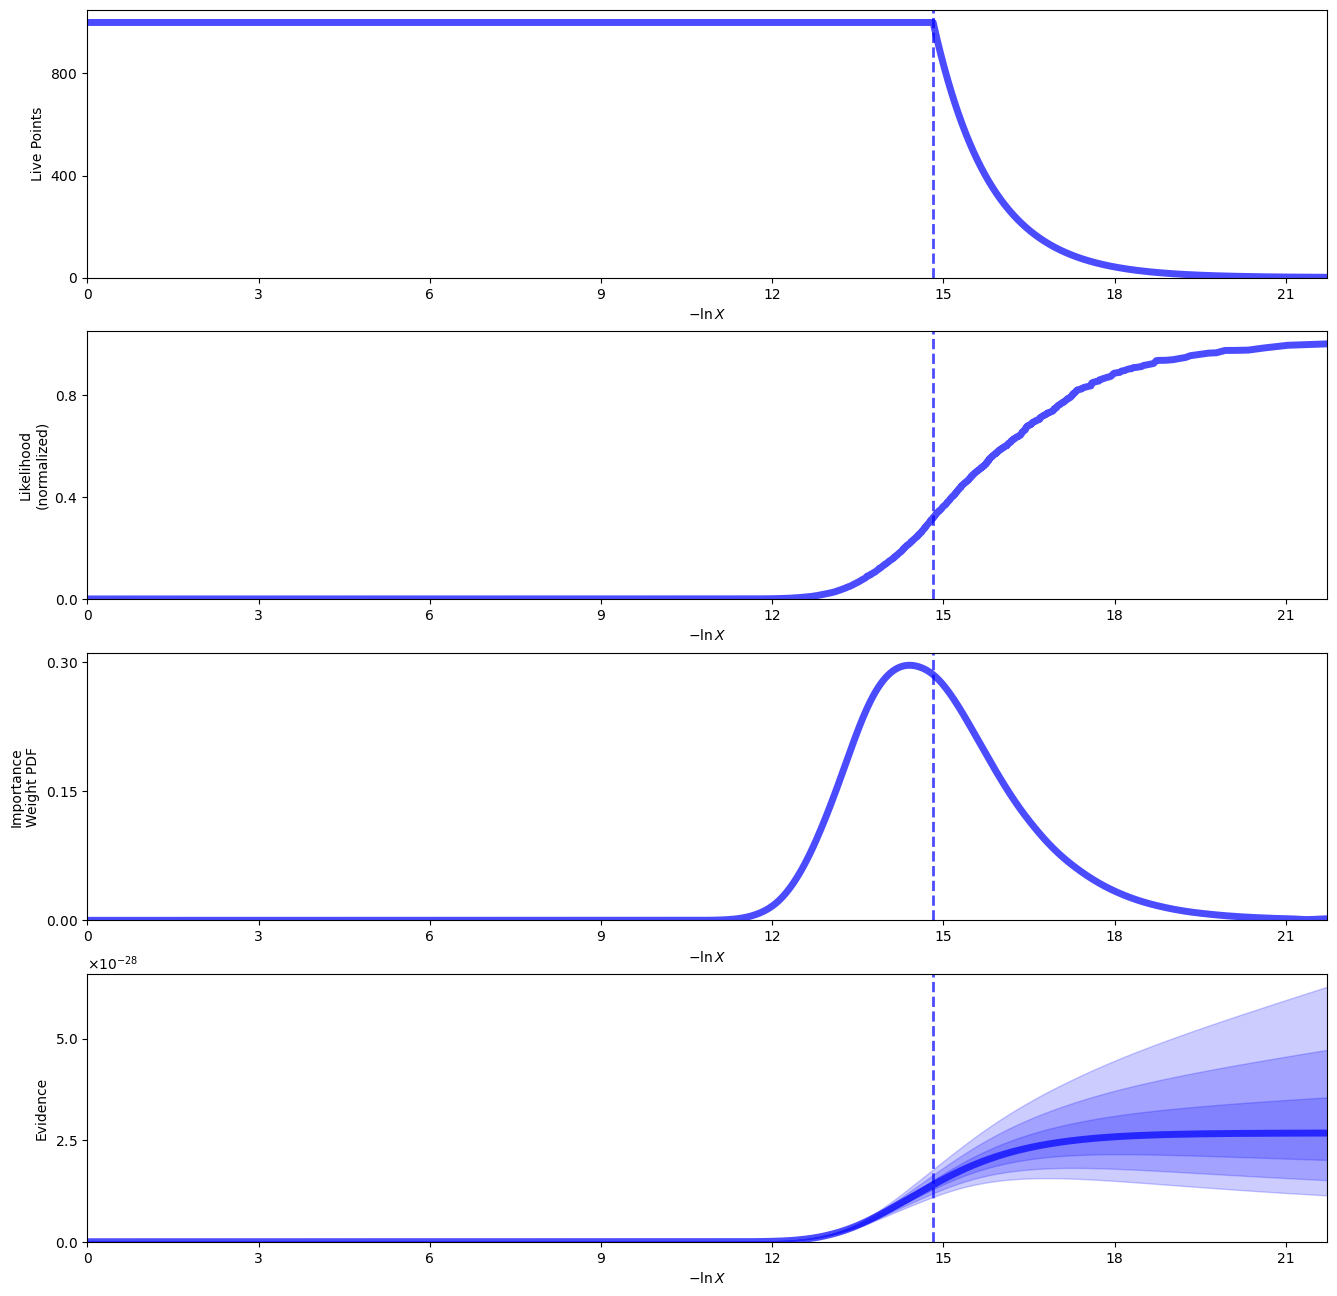

In [43]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

68% parameter credible regions are:
 [[4.163860456316425, 7.277899554237479], [10.174368872538569, 10.419903021653093], [0.0997432614519028, 0.15219176707862342], [47.589406118880234, 51.0906732056025]]

Mean and covariance of parameters are: [ 5.71327927 10.29462404  0.12603757 49.29298008],
 [[ 2.86438242e+00  9.16848344e-03  2.75404136e-02 -1.72881287e+00]
 [ 9.16848344e-03  1.51105095e-02  1.27851818e-03 -7.74074064e-04]
 [ 2.75404136e-02  1.27851818e-03  7.79298565e-04 -1.99866523e-03]
 [-1.72881287e+00 -7.74074064e-04 -1.99866523e-03  2.28132038e+00]]


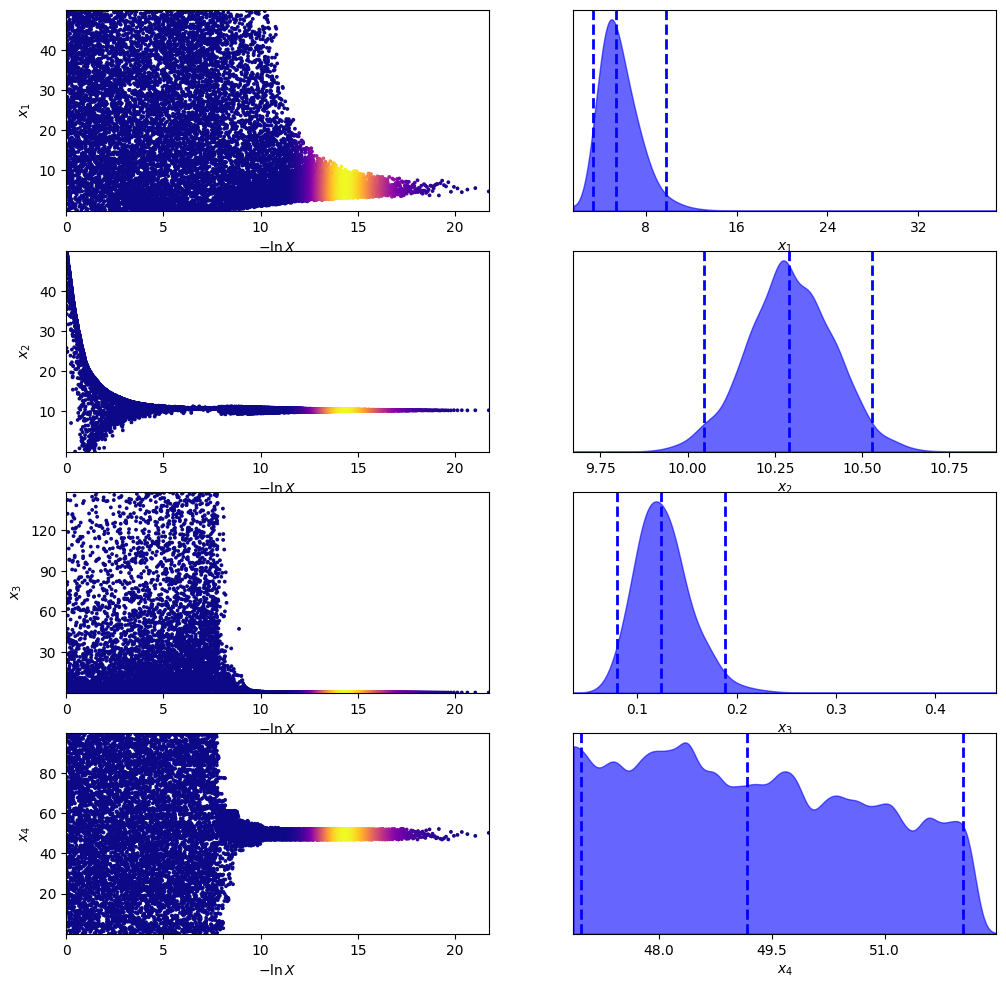

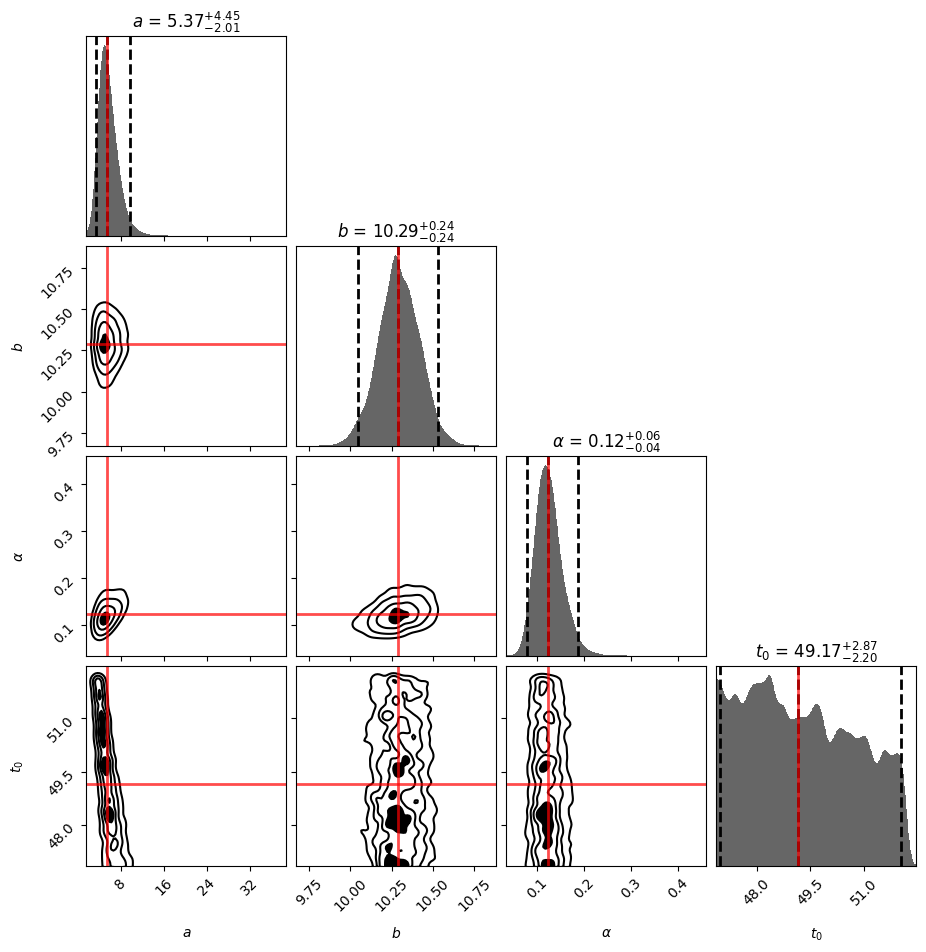

In [44]:
tfig, taxes = dyplot.traceplot(sresults)
samples = sresults.samples
weights = np.exp(sresults.logwt-sresults.logz[-1])
truths = [dyfunc.quantile(samps, 0.5, weights = weights) for samps in samples.T] #50th percentile of samples

#Corner plot
cfig, caxes = dyplot.cornerplot(sresults,truths=truths,
    show_titles=True,
    title_fmt=".2f",   
    labels=[r"$a$", r"$b$", r"$\alpha$", r"$t_{0}$"] )
evidence = sresults.logz[-1]

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights = weights) for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(f'Mean and covariance of parameters are: {mean},\n {cov}')


Using nested sampling, results similar to those obtained with MCMC are achieved.

### Gaussian model
In this section we want to run Nested sampling with a different model:
$$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$$


Our aim is to estimate the parameters of the model and compare it with the previous one.

In [45]:
def gauss_model(t, a, b, sigma_w, t0):
    return b + a * np.exp(-(t-t0)**2 /(2*sigma_w**2))
#Defining prior volume: loguniform between -2, 2 for the width and uniform for the other parameters   
def ptform_gauss(u):
    a, b, sigma_w, t0 = u
    
    sigm = loguniform.ppf(sigma_w, np.exp(-2), np.exp(2))
    return np.array([50 * a, 50 * b, sigm, 100 * t0])
    
def log_likelihood_g(theta, t, y, sigma):
    a, b, sigma_w, t0 = theta
    model_vals = gauss_model(t, a, b, sigma_w, t0)
    return -0.5 * np.sum(((y - model_vals) / sigma) ** 2)

def log_posterior(theta, t, y, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, sigma)

import dynesty

In [46]:
sampler_g = dynesty.NestedSampler(log_likelihood_g, ptform_gauss, ndim, logl_args=(time, flux, err), nlive = 1000) 
sampler_g.run_nested()
sresults_g = sampler_g.results


C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
15477it [01:15, 205.00it/s, +1000 | bound: 106 | nc: 1 | ncall: 194334 | eff(%):  8.523 | loglstar:   -inf < -52.450 <    inf | logz: -67.917 +/-  0.132 | dlogz:  0.001 >  1.009]


68% parameter credible regions are:
 [[2.3890833295118177, 3.117606438529089], [10.204473689823269, 10.440193256160214], [4.42437068731164, 6.074389627544845], [54.415524149566316, 56.392805346525456]]

Mean and covariance of parameters are: [ 2.75777369 10.32090977  5.25365524 55.41543453],
 [[ 0.14001486 -0.00848602 -0.1249917  -0.1213304 ]
 [-0.00848602  0.01413763 -0.03785092 -0.02017146]
 [-0.1249917  -0.03785092  0.69091083  0.26459346]
 [-0.1213304  -0.02017146  0.26459346  0.98802573]]


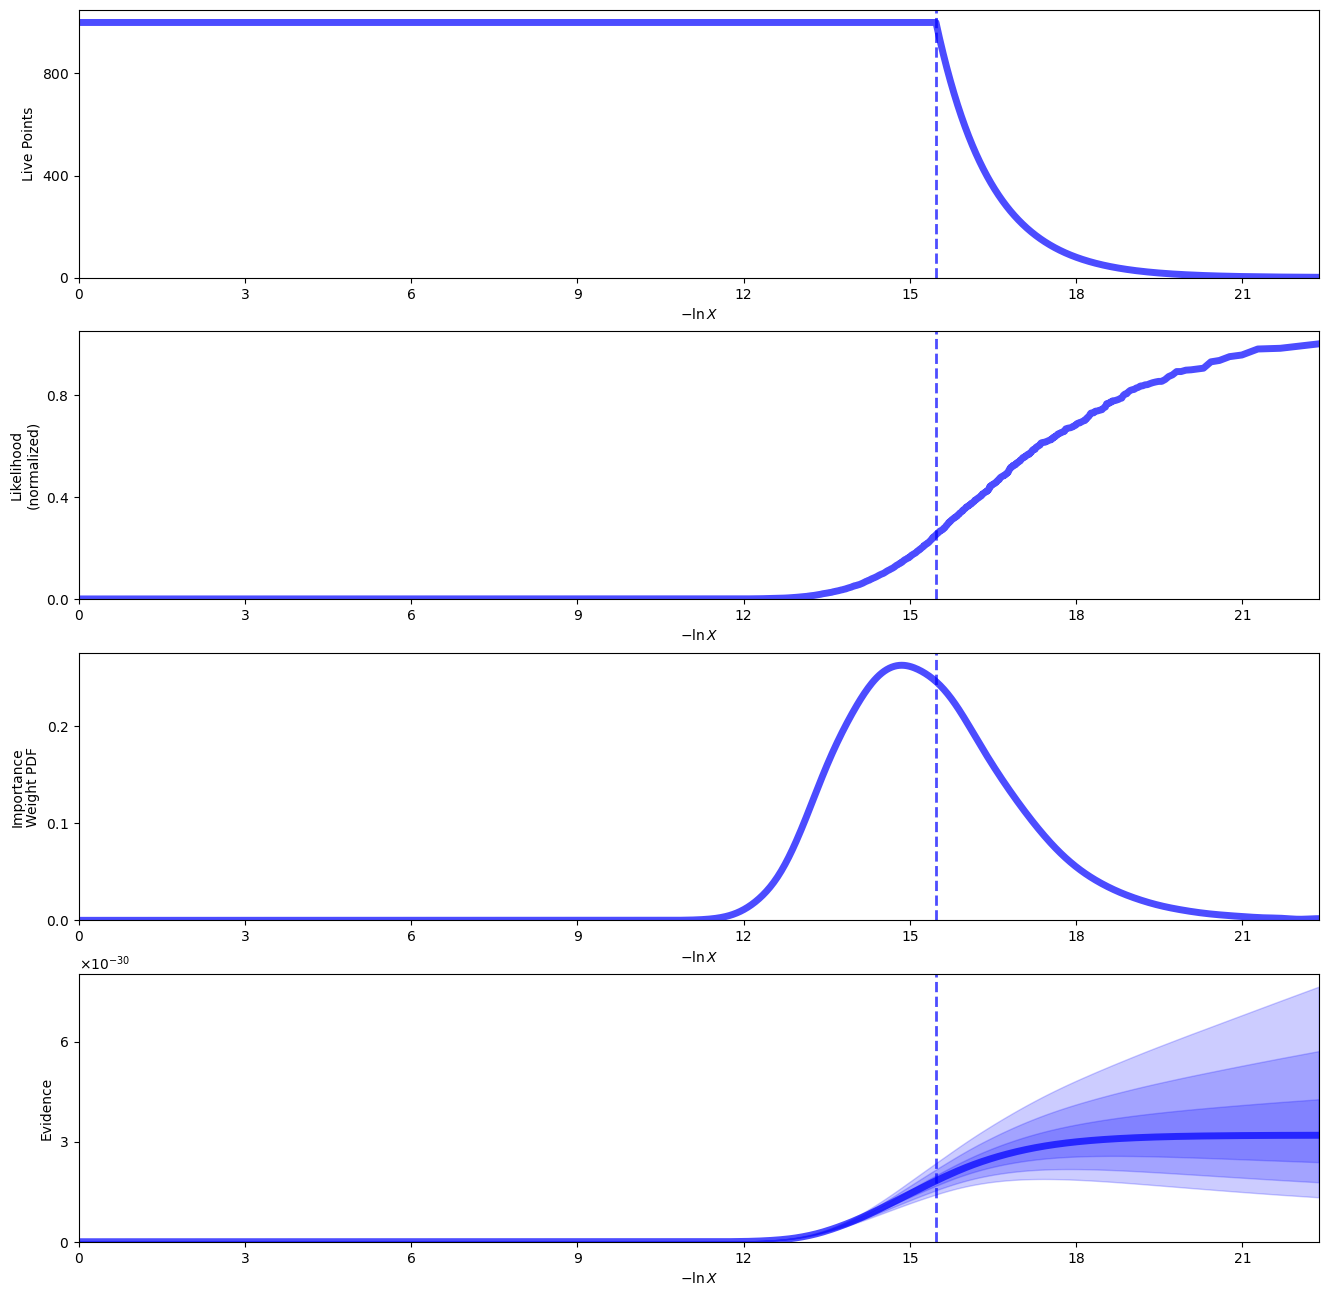

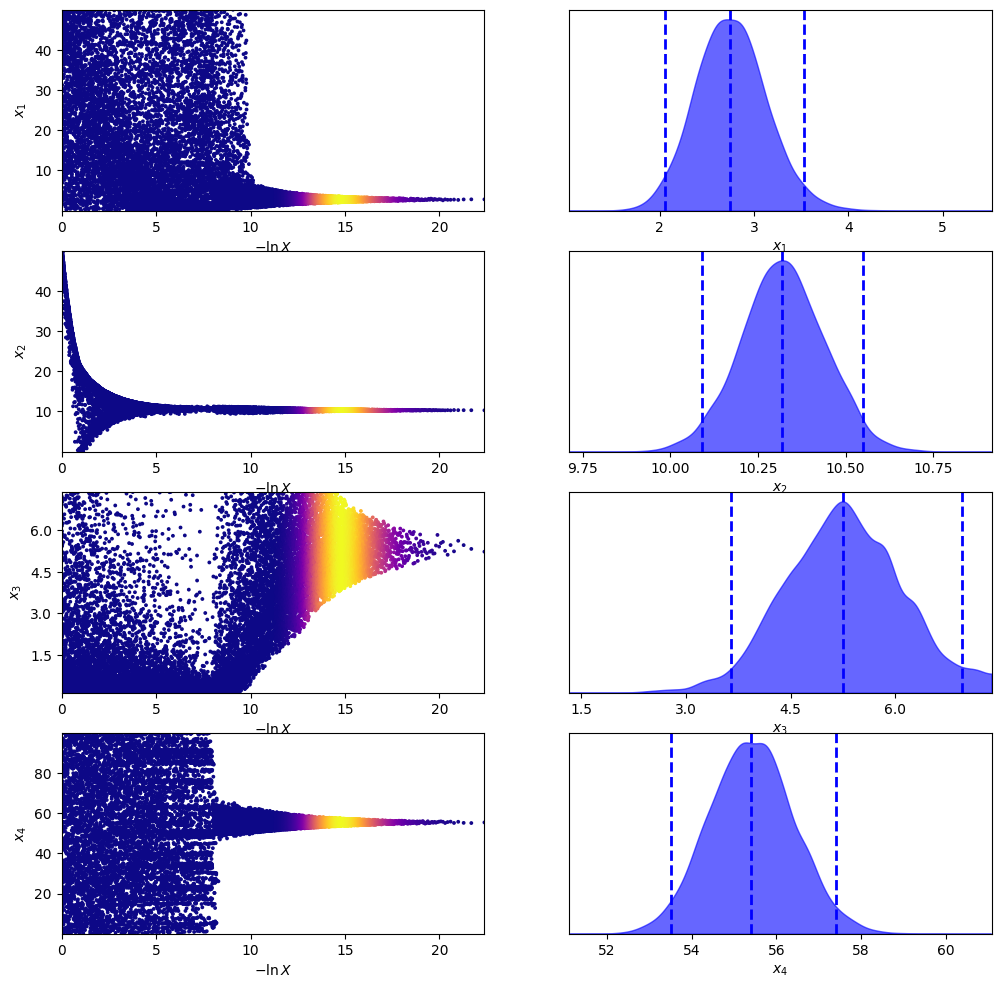

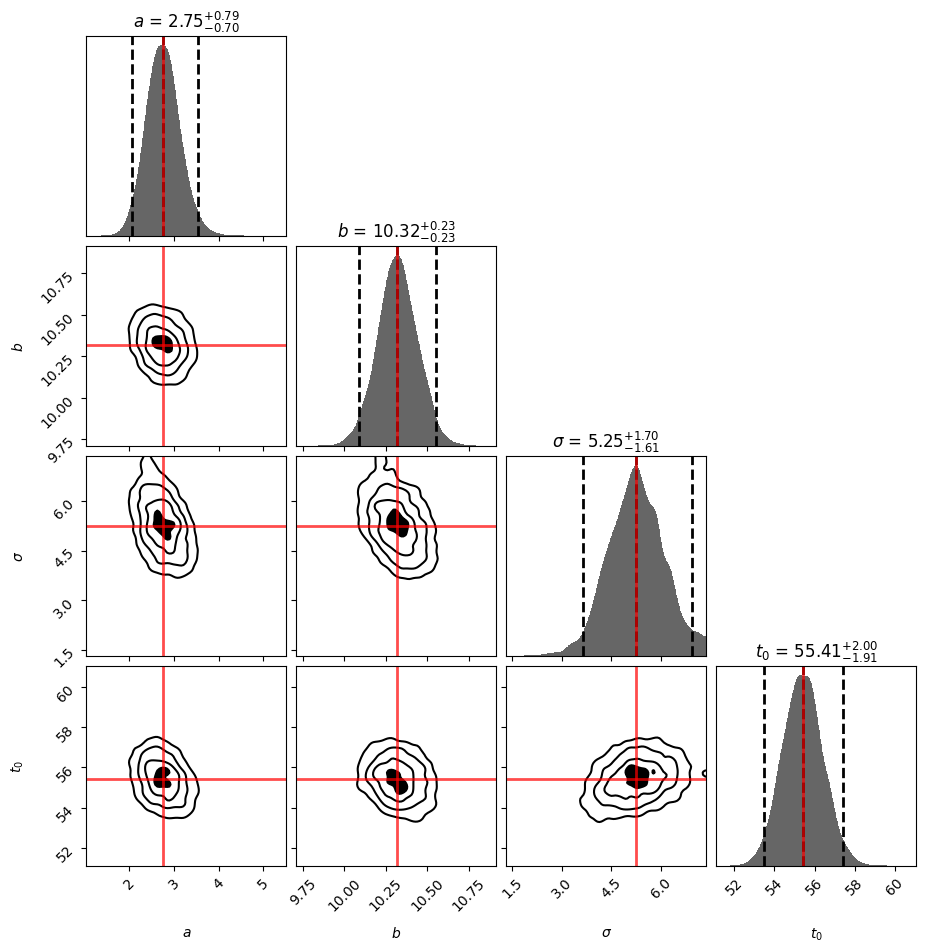

In [47]:
rfig, raxes = dyplot.runplot(sresults_g)
tfig, taxes = dyplot.traceplot(sresults_g)
samples_g = sresults_g.samples

weights_g = np.exp(sresults_g.logwt-sresults_g.logz[-1])

truths_g = [dyfunc.quantile(samps, 0.5, weights = weights_g) for samps in samples_g.T]
#Corner plot
cfig, caxes = dyplot.cornerplot(sresults_g, truths=truths_g,
    show_titles=True,
    title_fmt=".2f",  
    labels=[r"$a$", r"$b$", r"$\sigma$", r"$t_{0}$"] )

#Computing evidence
evidence_g = sresults_g.logz[-1]

quantiles_g = [dyfunc.quantile(samps, [0.16, 0.84], weights = weights_g) for samps in samples_g.T]
print('68% parameter credible regions are:\n ' + str(quantiles_g) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples_g, weights_g)
print(f'Mean and covariance of parameters are: {mean},\n {cov}')


### Model selection:

In [48]:
bayes_evidence = evidence_g/evidence 

In [49]:
print("bayes evidence", bayes_evidence)

bayes evidence 1.069750802497955


In [53]:
print(np.exp(sresults.logz[-1])/np.exp(sresults_g.logz[-1]))

83.79327233481433


The gaussian model is barely worth mentioning and there is very strong evidence in favour of the burst model
